# Figure 2 — the human receptor activation code

433 human receptors against 754 odorants. This notebook builds Fig. 2, Table 1, Extended Data
Figs 2–4 and the tables behind Supplementary Tables 2, 4, 5, 6 and 10, in the order the paper
uses them. The README says which file is which. Everything else about these receptors is in
`supplementary/`.

Needs the prediction matrices: `python scripts/download_zenodo_data.py`.

## 0 · Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.integrate import trapezoid
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, matthews_corrcoef, mean_squared_error,
                             precision_score, recall_score, roc_auc_score)

warnings.filterwarnings("ignore")   # library deprecation notices only
%config InlineBackend.figure_format = 'png'

REPO = Path("../../..").resolve()
sys.path.append(str(REPO / "Downstream_Analysis/scripts"))
sys.path.append(str(REPO / "scripts"))
import activation_code as ac
import activation_figures as af
from calibration import bin_reweighted_prevalence, receptor_weighted_prevalence
from plotting_functions import FIGSIZE, custom_plots

plt.rcParams.update(custom_plots())

PROBABILITIES = REPO / "Downstream_Analysis/predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
M2OR_PAIRS = REPO / "Model_Inputs/Data_Preparation/processed/m2or_pairs_model.csv"
ODOURS = REPO / "Chemicals/processed_data/m2or_inchi_odors_smiles.csv"
PATHWAYS = REPO / "Chemicals/processed_data/ligand_pathways.csv"
FASTA = REPO / "Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
CLASSES = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv"
TREE = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree"

FIGURES = Path("Figures")
TABLES = Path("Tables")
FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)
NAME = "hybrid_density"     # the suffix every output file of the main matrix carries

## 1 · Model check — Extended Data Fig. 2, Supplementary Table 4

409 of the 433 receptors have at least one measured M2OR result, which gives the measured
pairs below. Everything in this section is computed on those pairs only.

The cut here is the score at which the predicted binding rate equals the measured rate. It is
used for the confusion matrix and the metrics, and for nothing else: recall at this cut is
about 0.6, so it would under-fill a matrix.

In [2]:
common_pairs, probability_grid, human_probabilities, _ = ac.tested_pairs_table(PROBABILITIES, M2OR_PAIRS, FASTA)

print(f"measured pairs     : {len(common_pairs):,}")
print(f"  binding          : {(common_pairs['experimental'] == 1).sum():,}")
print(f"  not binding      : {(common_pairs['experimental'] == 0).sum():,}")
print(f"  receptors        : {common_pairs['sequence'].nunique()}")
print(f"  odorants         : {common_pairs['smiles_id'].nunique()}")
print(f"  wild-type pairs  : {(~common_pairs['mutation']).sum():,}")
print(f"  mutant pairs     : {common_pairs['mutation'].sum():,}")

measured pairs     : 23,782
  binding          : 1,128
  not binding      : 22,654
  receptors        : 409
  odorants         : 652
  wild-type pairs  : 23,594
  mutant pairs     : 188


measured binding rate          : 4.7431%
AUROC                          : 0.9699
predicted binding rate at 0.5  : 17.1895%
rate-matched cut               : 0.9150
  MCC highest at               : 0.920
  F1 highest at                : 0.920


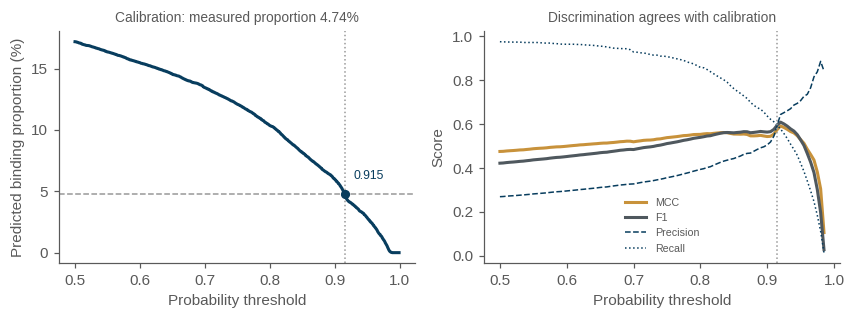

In [3]:
y_true = common_pairs["experimental"].values
y_score = common_pairs["probability"].values
measured_rate = y_true.mean()
CUT = ac.rate_matched_cut(y_score, y_true)

# Fine grid for the rate curve; coarser for the metrics, which refit a confusion matrix each time.
fine = np.arange(0.50, 0.9990, 0.0001)
predicted_rate = ac.binding_rate_by_threshold(y_score, fine)
coarse = np.arange(0.50, 0.990, 0.005)
calls = [(y_score > t).astype(int) for t in coarse]
mcc = np.array([matthews_corrcoef(y_true, c) for c in calls])
f1 = np.array([f1_score(y_true, c, zero_division=0) for c in calls])
precision = np.array([c[y_true == 1].sum() / c.sum() if c.sum() else np.nan for c in calls])
recall = np.array([c[y_true == 1].sum() / (y_true == 1).sum() for c in calls])

print(f"measured binding rate          : {measured_rate:.4%}")
print(f"AUROC                          : {roc_auc_score(y_true, y_score):.4f}")
print(f"predicted binding rate at 0.5  : {(y_score > 0.5).mean():.4%}")
print(f"rate-matched cut               : {CUT:.4f}")
print(f"  MCC highest at               : {coarse[mcc.argmax()]:.3f}")
print(f"  F1 highest at                : {coarse[f1.argmax()]:.3f}")

af.threshold_calibration(fine, predicted_rate, coarse, mcc, f1, precision, recall, measured_rate, CUT,
                         FIGSIZE, FIGURES / "threshold_calibration.svg")

The pairs with their binary call go to `Tables/exp_pred_common_pairs.csv`. Supplementary
Table 4 and `supplementary/S1.model_errors` are built from it.

In [4]:
common_pairs["predicted"] = (common_pairs["probability"] > CUT).astype(int)
common_pairs = common_pairs[["uniprot_id", "seq_id", "sequence", "smiles_id", "SMILES",
                             "experimental", "predicted", "probability", "mutation", "OR_class"]]
common_pairs.to_csv(TABLES / "exp_pred_common_pairs.csv", index=False)
print(f"predicted binding rate at the cut : {common_pairs['predicted'].mean():.4%}")
print(f"measured binding rate             : {common_pairs['experimental'].mean():.4%}")

predicted binding rate at the cut : 4.7431%
measured binding rate             : 4.7431%


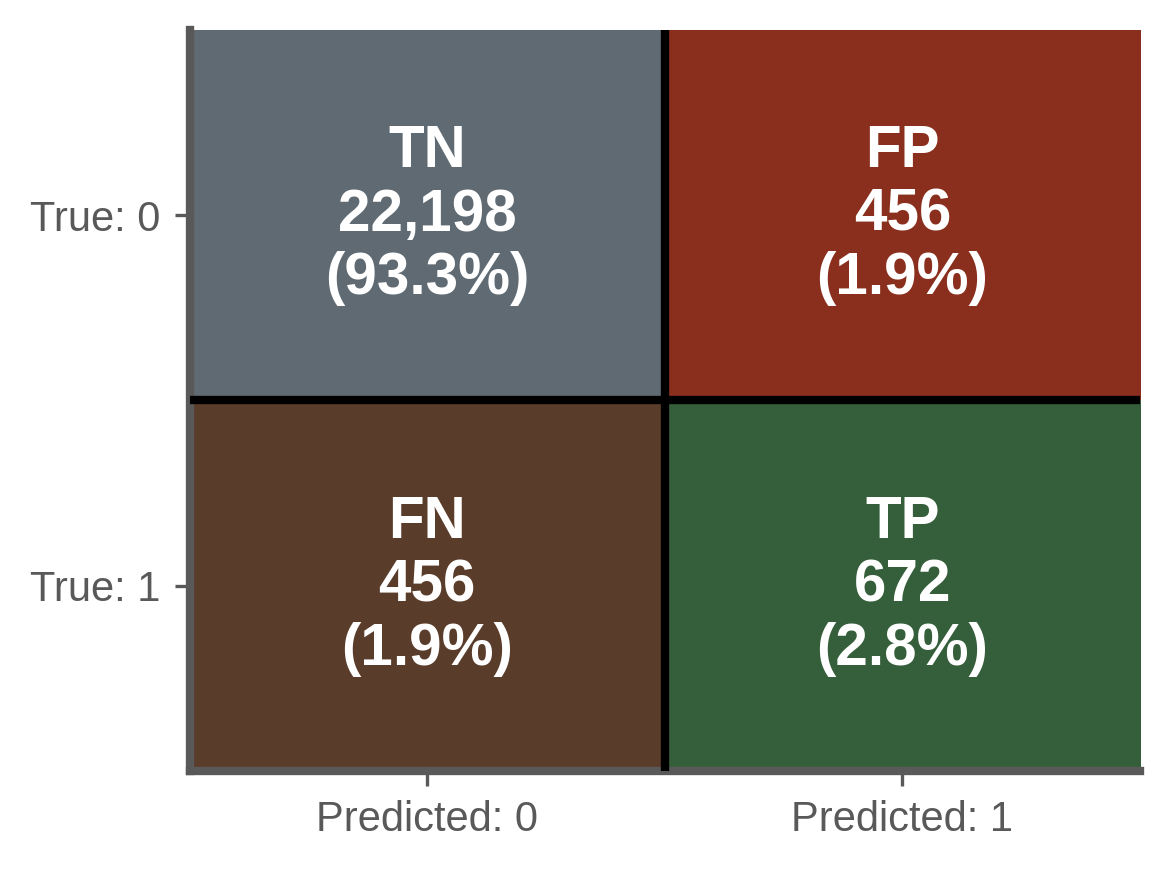

In [5]:
tn, fp, fn, tp = confusion_matrix(common_pairs["experimental"], common_pairs["predicted"]).ravel()
af.confusion_matrix_figure(tn, fp, fn, tp, FIGURES / "confusion_matrix_common_pairs.svg")

measured = common_pairs["experimental"].to_numpy()
predicted = common_pairs["predicted"].to_numpy()
common_pairs["cm_category"] = np.where(measured == 1, np.where(predicted == 1, "TP", "FN"),
                                       np.where(predicted == 1, "FP", "TN"))

Threshold-free metrics use the probability; the rest use the call at the cut.

In [6]:
y_true = common_pairs["experimental"]
y_pred = common_pairs["predicted"]
y_score = common_pairs["probability"]
metrics = pd.DataFrame({
    "Metric": ["ROC AUC", "PR AUC", "Pearson r (probability vs label)", "Kendall τ (probability vs label)",
               "Balanced Accuracy", "Accuracy", "MCC", "F1", "Precision (PPV)",
               "Recall = Sensitivity (TP rate)", "Specificity (TN rate)", "RMSE (probability vs label)"],
    "Value": [roc_auc_score(y_true, y_score), average_precision_score(y_true, y_score),
              stats.pearsonr(y_true, y_score).statistic, stats.kendalltau(y_true, y_score).statistic,
              balanced_accuracy_score(y_true, y_pred), accuracy_score(y_true, y_pred),
              matthews_corrcoef(y_true, y_pred), f1_score(y_true, y_pred), precision_score(y_true, y_pred),
              recall_score(y_true, y_pred), tn / (tn + fp), np.sqrt(mean_squared_error(y_true, y_score))],
}).set_index("Metric")
metrics["Value"] = metrics["Value"].round(4)
metrics

,Value
Metric,
ROC AUC,0.9699
PR AUC,0.6279
Pearson r (probability vs label),0.5217
Kendall τ (probability vs label),0.2825
Balanced Accuracy,0.7878
Accuracy,0.9617
MCC,0.5756
F1,0.5957
Precision (PPV),0.5957


Each category's density integrates to 1, with one shared bandwidth and reflection at 0 and 1,
so the heights can be compared and no mass is lost off the ends.

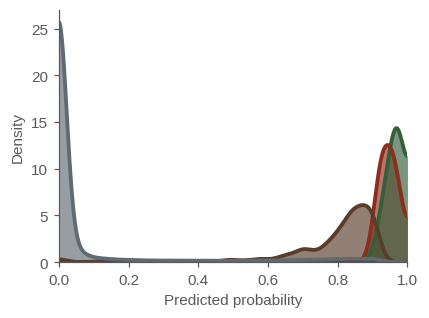

TN: peak  25.70   area 1.0000
FN: peak   6.11   area 1.0000
FP: peak  12.54   area 1.0000
TP: peak  14.35   area 1.0000


In [7]:
KDE_BANDWIDTH = 0.02
KDE_GRID = np.linspace(0, 1, 2000)
densities = {category: af.bounded_kde(common_pairs.loc[common_pairs["cm_category"] == category, "probability"],
                                      KDE_BANDWIDTH, KDE_GRID)
             for category in ["TN", "FN", "FP", "TP"]}
counts = {category: int((common_pairs["cm_category"] == category).sum()) for category in ["TN", "FN", "FP", "TP"]}
af.probability_by_category(densities, counts, KDE_GRID, FIGSIZE,
                           FIGURES / "probability_density_by_confusion_matrix_category.svg")
for category in ["TN", "FN", "FP", "TP"]:
    print(f"{category}: peak {densities[category].max():6.2f}   area {trapezoid(densities[category], KDE_GRID):.4f}")

One point per receptor; the denominator is the odorants measured on that receptor.

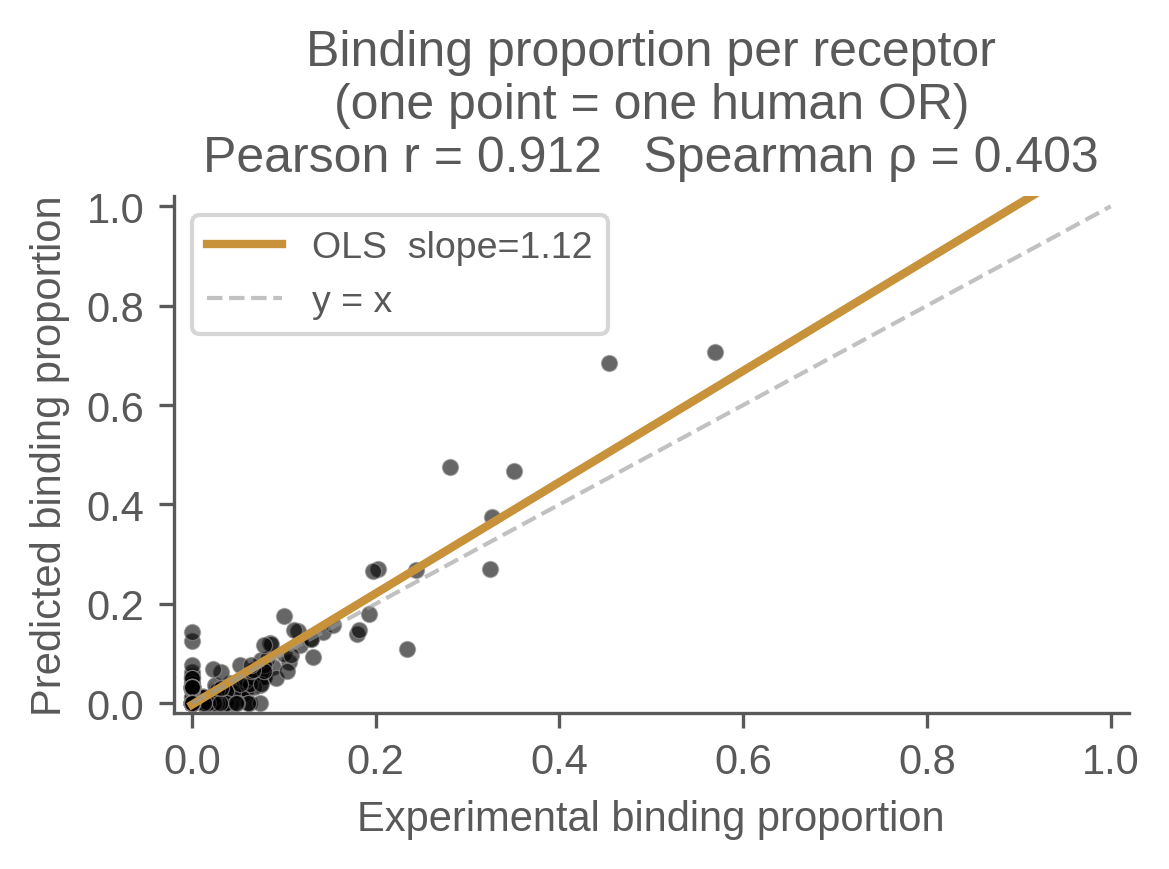

In [8]:
receptor_proportions = (common_pairs.groupby("sequence")
                        .agg(exp_prop=("experimental", "mean"), pred_prop=("predicted", "mean"),
                             n_pairs=("experimental", "count"))
                        .reset_index())
af.binding_proportion_scatter(receptor_proportions, "Binding proportion per receptor\n(one point = one human OR)",
                              FIGURES / "proportions_scatter.svg")

## 2 · The hybrid matrix and its six clusters — Fig. 2a, Extended Data Fig. 3

Isotonic regression maps model score to measured binding frequency, fitted once on the
measured pairs. Over the untested cells the calibrated probabilities add up to N, the number
of binders expected there; the N highest-scoring cells are called. The score of the Nth cell
is the density cut, which comes out of the fill rather than being chosen. Measured values are
then written over the top.

The odorants with at least one call are clustered on the Jaccard distance between their
receptor columns (PAM, k = 6). Clusters are named after their enriched odour descriptors
(section 5).

In [9]:
data = ac.load_activation_data(PROBABILITIES, M2OR_PAIRS, FASTA)
fill = data.fill

print(f"human probability matrix   : {data.scores.shape}")
print(f"measured pairs matched     : {len(data.measured):,}  (binding {data.measured_labels.sum():,})")
print(f"measured binding rate      : {100 * data.measured_labels.mean():.4f}%")
print(f"rate-matched cut           : {data.rate_matched_cut:.4f}   (reported only)")
print()
print(fill.summary())
print(f"expected binders N         : {fill.n_expected} of {fill.n_untested} untested cells")
print(f"measured binders kept      : {fill.n_experimental_pos}")
print(f"odorants with no call      : {fill.orphan_ligands}")

# The overlay can make orphans: a receptor whose only above-cut cells were measured and
# found not to bind loses them. Those are model false positives M2OR already ruled out.
orphans_plain_cut = int(((data.scores > fill.cut).sum(1) == 0).sum())
orphans_from_overlay = int(sum(1 for i in np.where(data.hybrid.sum(1) == 0)[0] if (data.scores[i] > fill.cut).any()))
print(f"\norphan receptors at a plain cut > {fill.cut:.4f} : {orphans_plain_cut}")
print(f"  of our {fill.orphan_receptors}, made by the overlay       : {orphans_from_overlay}")
print(f"  orphan either way                      : {fill.orphan_receptors - orphans_from_overlay}")

# Two independent estimates of the grid's binding rate, as a check on the fill's density.
print(f"\nreceptor-weighted estimate : {100 * receptor_weighted_prevalence(data.measured_rows, data.measured_labels):.4f}%")
print(f"bin-reweighted estimate    : {100 * bin_reweighted_prevalence(data.measured_scores, data.measured_labels, data.scores.ravel()):.4f}%")
print(f"density fill               : {100 * fill.density:.4f}%")

human probability matrix   : (433, 754)
measured pairs matched     : 23,782  (binding 1,128)
measured binding rate      : 4.7431%
rate-matched cut           : 0.9150   (reported only)

grid density        : 2.7453%
density cut (output): 0.8917
orphaned receptors  : 58
expected binders N         : 7835 of 302700 untested cells
measured binders kept      : 1128
odorants with no call      : 67

orphan receptors at a plain cut > 0.8917 : 5
  of our 58, made by the overlay       : 55
  orphan either way                      : 3

receptor-weighted estimate : 2.6013%
bin-reweighted estimate    : 2.7951%
density fill               : 2.7453%


In [10]:
smiles_by_odorant, tags_by_odorant = ac.odour_tags(M2OR_PAIRS, ODOURS, data.odorant_ids)
class_of = ac.receptor_classes(CLASSES)
tree_order = ac.tree_tip_order(TREE)
assert set(tree_order) == set(data.receptor_ids)

print(f"odorants with odour descriptors : {len(tags_by_odorant)} / {len(data.odorant_ids)}")
print(f"Class I {sum(v == 'I' for v in class_of.values())}, Class II {sum(v == 'II' for v in class_of.values())}")

odorants with odour descriptors : 575 / 754
Class I 62, Class II 371


In [11]:
clustered_ids, clustered_matrix, labels = ac.cluster_odorants(data.hybrid, data.odorant_ids)
enrichment = ac.tag_enrichment(clustered_ids, labels, tags_by_odorant)
significant = ac.significant_enrichment(enrichment)
info, display_order = ac.name_clusters(enrichment, labels)

for i, c in enumerate(display_order):
    print(f"C{i + 1}  {info[c]['name']:28s} n = {info[c]['size']}")
print(f"significant descriptor enrichments: {len(significant)}")

C1  Acid / Dairy / Cheese        n = 70
C2  Roasted / Phenolic / Spice   n = 100
C3  Floral / Balsamic            n = 127
C4  Fruity / Fatty / Aldehydic   n = 214
C5  Fermented / Solvent          n = 68
C6  Smoky                        n = 108
significant descriptor enrichments: 30


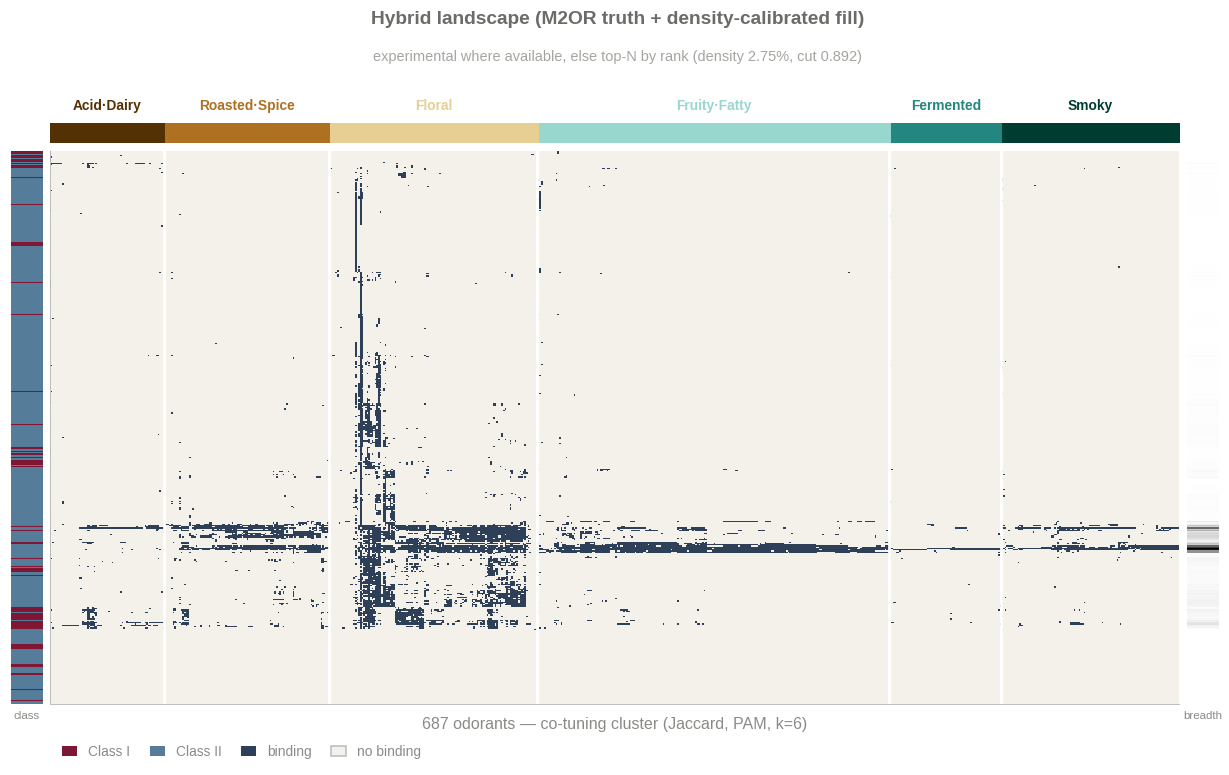

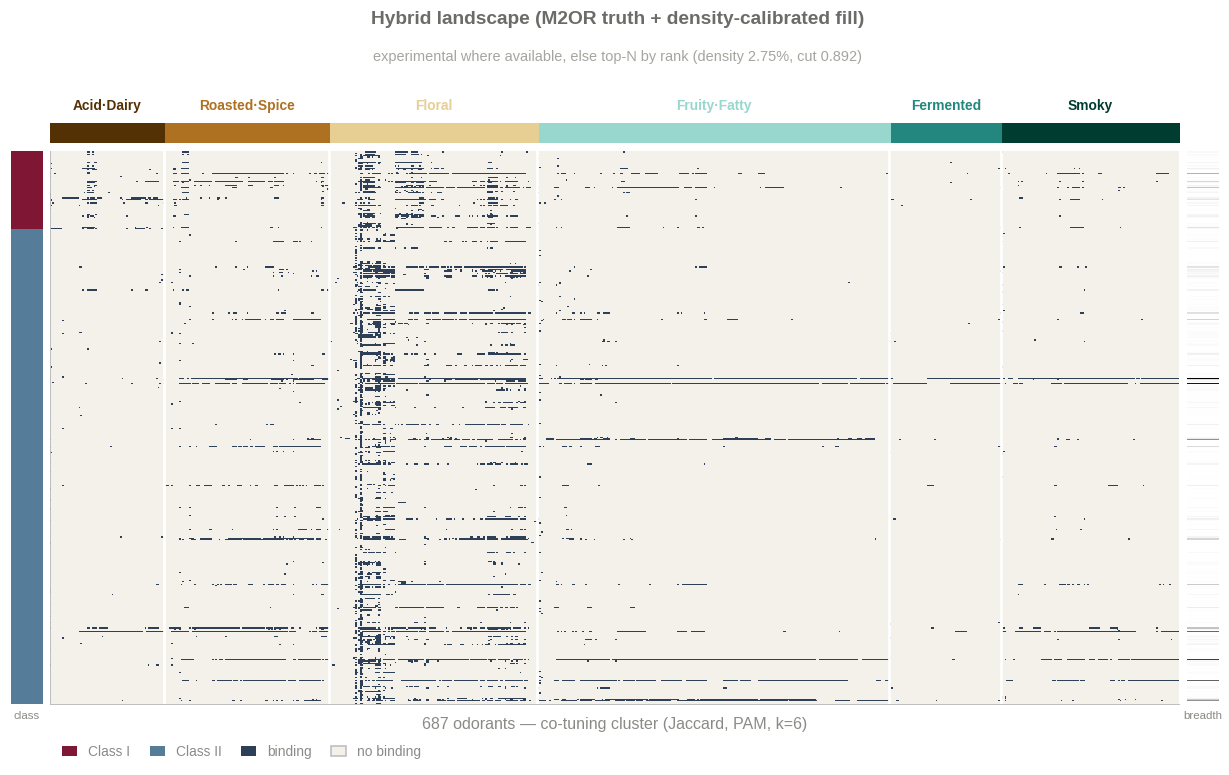

In [12]:
title = "Hybrid landscape (M2OR truth + density-calibrated fill)"
subtitle = f"experimental where available, else top-N by rank (density {fill.density:.2%}, cut {fill.cut:.3f})"
af.activation_heatmap(clustered_ids, clustered_matrix, labels, info, display_order, data.receptor_ids, class_of,
                      title, subtitle, FIGURES / f"heatmap_{NAME}.svg", row_order="cotuning", show=True)
af.activation_heatmap(clustered_ids, clustered_matrix, labels, info, display_order, data.receptor_ids, class_of,
                      title, subtitle, FIGURES / f"heatmap_{NAME}_tree_order.svg", row_order="tree", show=True,
                      tree_order=tree_order)

## 3 · Ligands per receptor by class — Fig. 2b, Supplementary Table 2

Counted over the whole hybrid matrix, so receptors with no ligand (orphans) stay in. Bars are
% of each class, since Class II has six times as many receptors; the counts are above the bars.

Class I   n= 62  median  8.5  mean   27.4  max  221  orphans   9
Class II  n=371  median    4  mean   19.6  max  539  orphans  49
all receptors     Mann-Whitney p = 0.0185   Cliff delta = +0.186   shift +2 ligands [95% CI +0, +8]
orphans excluded  Mann-Whitney p = 0.00167   Cliff delta = +0.269   shift +5 ligands [95% CI +1, +14]


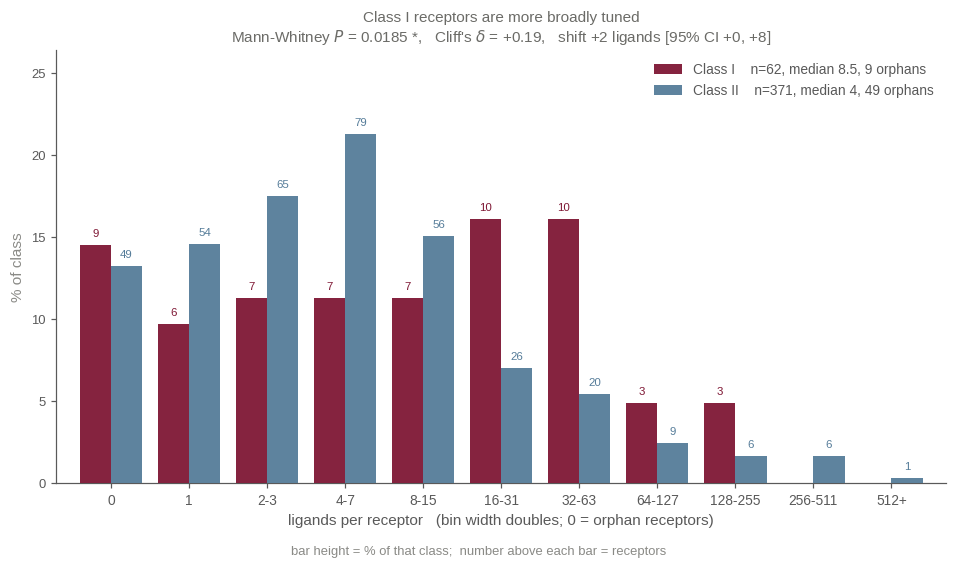

In [13]:
breadth = ac.tuning_breadth(data.hybrid, data.receptor_ids, class_of)
breadth["table"].to_csv(TABLES / "class_tuning_breadth.csv", index=False)

for label, values in [("Class I", breadth["class_I"]), ("Class II", breadth["class_II"])]:
    print(f"{label:9s} n={len(values):3d}  median {np.median(values):>4g}  mean {values.mean():6.1f}  "
          f"max {values.max():4d}  orphans {(values == 0).sum():3d}")
for label, p, delta, (shift, low, high) in [
        ("all receptors   ", breadth["p_all"], breadth["delta_all"], breadth["shift_all"]),
        ("orphans excluded", breadth["p_bound"], breadth["delta_bound"], breadth["shift_bound"])]:
    print(f"{label}  Mann-Whitney p = {p:.3g}   Cliff delta = {delta:+.3f}   "
          f"shift {shift:+.0f} ligands [95% CI {low:+.0f}, {high:+.0f}]")

af.breadth_histogram(breadth, FIGURES / "class_tuning_breadth_hist.svg")

## 4 · What each class reads — Fig. 2c (with inset) and 2d

An odorant is read by a class when it activates at least 1/62 of that class: one Class I
receptor, or six Class II receptors. The same rate for both, so class size does not decide it.

Fig. 2c and its inset compare the two exclusive sets, class I only against class II only; the
shared set is drawn for context. Functional groups: Fisher per group, BH over the nine groups.
Inset: Cliff's delta with Mann-Whitney, BH over the ten descriptors. Fig. 2d uses the same two
sets, as a % of the odorants in each set that carry any odour descriptor.

In [14]:
groups, rate, rate_I, rate_II, in_I, in_II = ac.class_partition(data.hybrid, data.receptor_ids, class_of)
is_class_I = np.array([class_of[r] == "I" for r in data.receptor_ids])
set_sizes = {g: int((groups == g).sum()) for g in ac.CLASS_SETS}
unbound = int((data.hybrid.sum(0) == 0).sum())
print(f"rate {rate:.4f}   Class I only {set_sizes['Class I only']}   shared {set_sizes['shared']}   "
      f"Class II only {set_sizes['Class II only']}   below the rate in both {int((groups == '').sum()) - unbound}   "
      f"no call {unbound}")

# How many receptors stand behind each set: a receptor counts if it binds any odorant of the set.
for label, mask in [("shared", in_I & in_II), ("Class I only", in_I & ~in_II), ("Class II only", ~in_I & in_II)]:
    n_I, n_II = ac.receptors_reading(data.hybrid, is_class_I, mask)
    print(f"  {label:14s} read by {n_I}/{is_class_I.sum()} Class I and {n_II}/{(~is_class_I).sum()} Class II receptors")

class_descriptors = ac.class_set_descriptors(data.odorant_ids, smiles_by_odorant, groups, rate_I, rate_II, in_I, in_II)
class_descriptors.to_csv(TABLES / f"chemspace_{NAME}_descriptors.csv", index=False)

rate 0.0161   Class I only 111   shared 276   Class II only 112   below the rate in both 188   no call 67
  shared         read by 53/62 Class I and 317/371 Class II receptors
  Class I only   read by 30/62 Class I and 41/371 Class II receptors
  Class II only  read by 0/62 Class I and 124/371 Class II receptors


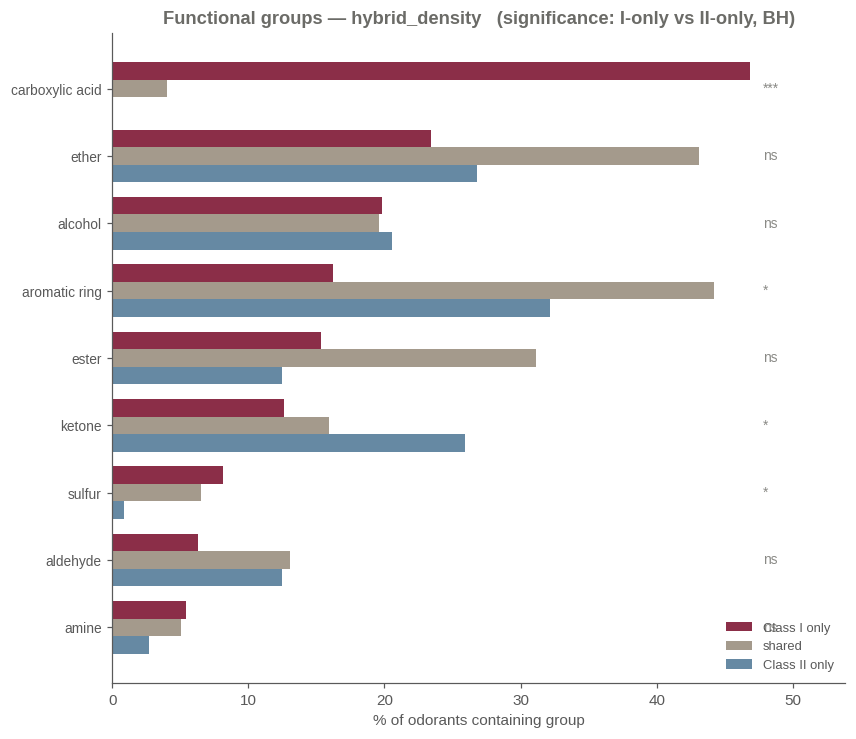

          group  Class I only  shared  Class II only     q
          amine         5.405   5.072          2.679 0.499
       aldehyde         6.306  13.043         12.500 0.302
         sulfur         8.108   6.522          0.893 0.030
         ketone        12.613  15.942         25.893 0.038
          ester        15.315  31.159         12.500 0.724
  aromatic ring        16.216  44.203         32.143 0.030
        alcohol        19.820  19.565         20.536 1.000
          ether        23.423  43.116         26.786 0.724
carboxylic acid        46.847   3.986          0.000 0.000


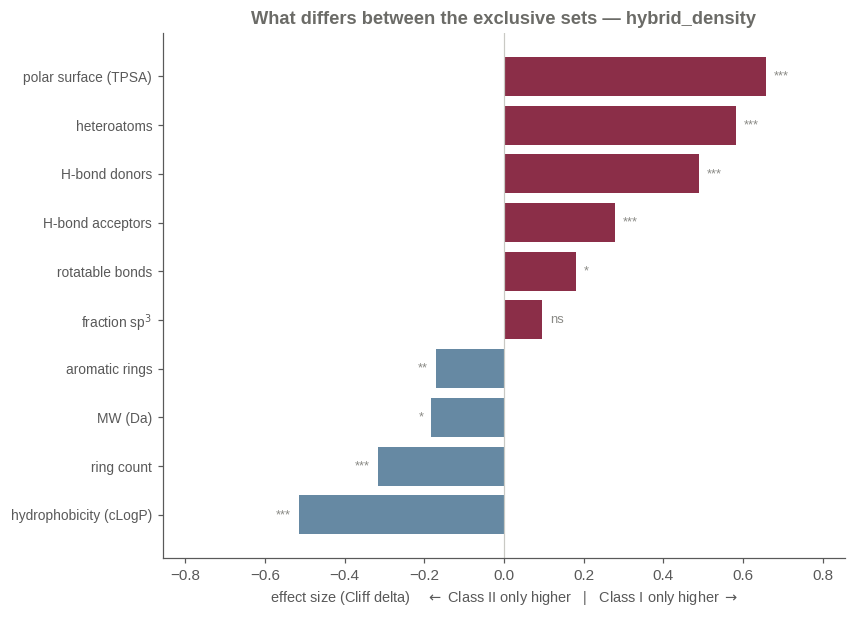

q < 0.05: hydrophobicity (cLogP) -0.51***  ring count -0.32***  MW (Da) -0.18*  aromatic rings -0.17**  rotatable bonds +0.18*  H-bond acceptors +0.28***  H-bond donors +0.49***  heteroatoms +0.58***  polar surface (TPSA) +0.66***


In [15]:
group_share = af.class_functional_groups(class_descriptors, NAME, FIGURES / f"chemspace_{NAME}_groups.svg", show=True)
print(group_share.round(3).to_string(index=False))

only_I = (class_descriptors.in_I & ~class_descriptors.in_II).values
only_II = (class_descriptors.in_II & ~class_descriptors.in_I).values
cliff_labels, cliff_effects, cliff_q = af.cliffs_figure(
    class_descriptors, only_I, only_II, f"What differs between the exclusive sets — {NAME}",
    FIGURES / f"chemspace_{NAME}_effects_cliffs.svg", show=True)
print("q < 0.05: " + "  ".join(f"{l} {e:+.2f}{ac.significance_stars(q)}"
                                for l, e, q in zip(cliff_labels, cliff_effects, cliff_q) if q < 0.05))

The CSV holds both comparisons, the exclusive sets (tested) and the full class sets
(percentages only, since they share 276 odorants). The full-set figure is in `supplementary/S3`.

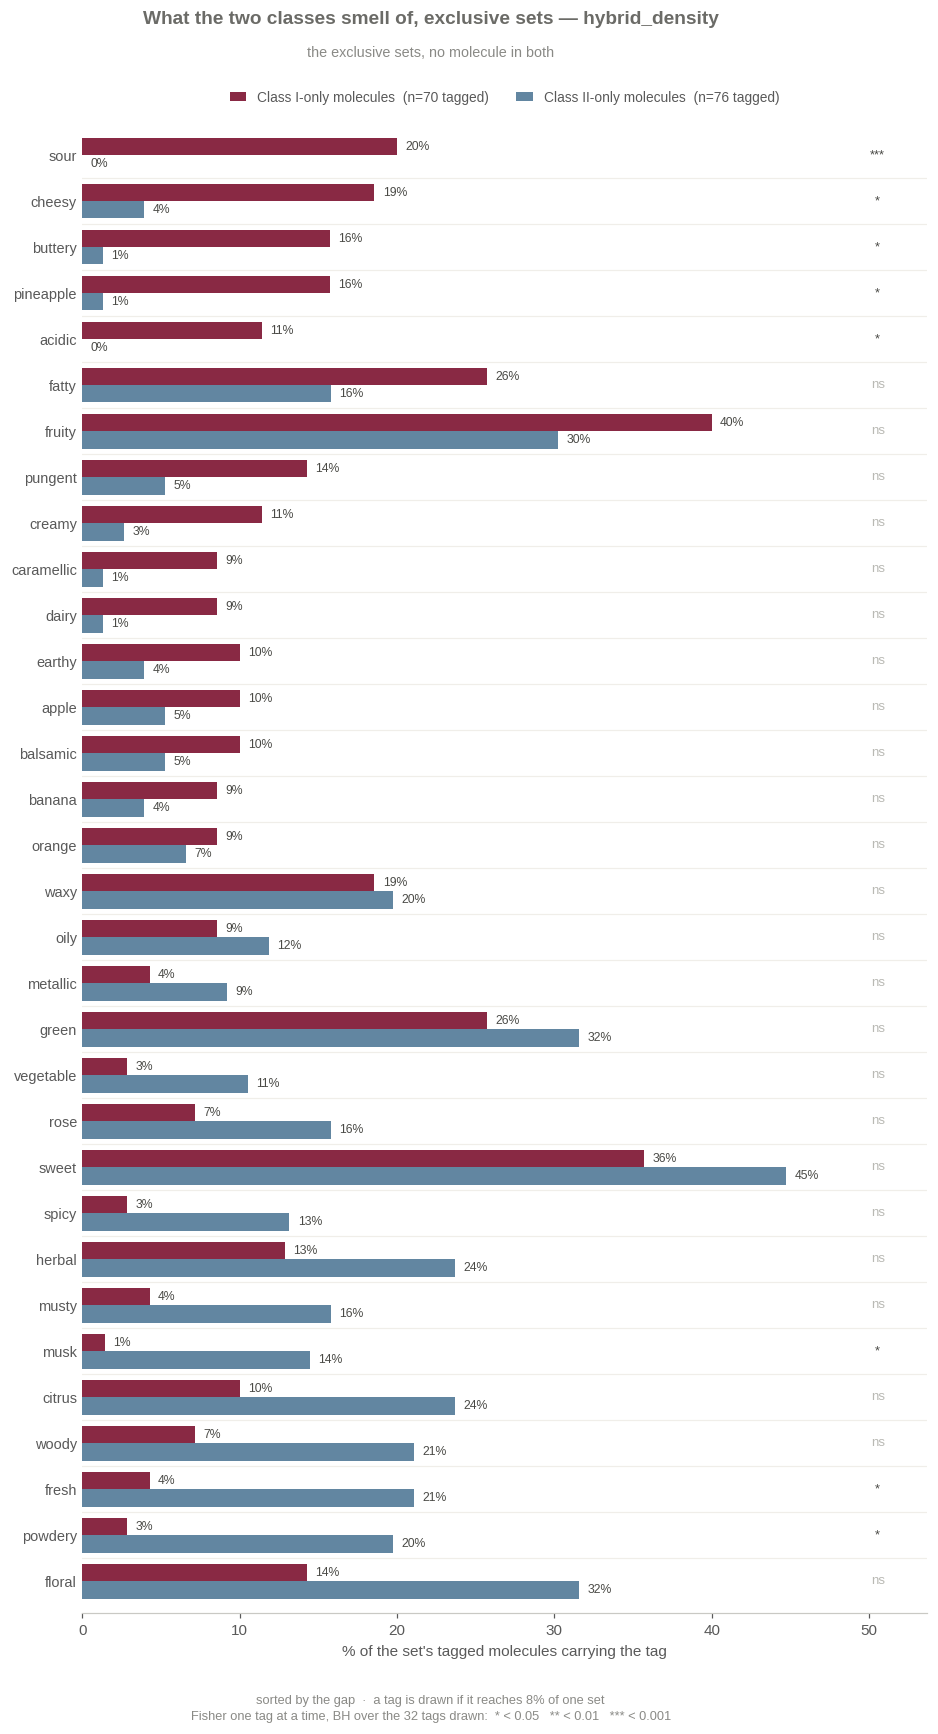

exclusive sets, q < 0.05: sour 20/0%***  cheesy 19/4%*  buttery 16/1%*  pineapple 16/1%*  acidic 11/0%*  musk 1/14%*  fresh 4/21%*  powdery 3/20%*


In [16]:
tag_tables = []
for comparison, members_I, members_II, test in [("full bags", in_I, in_II, False),
                                                ("exclusive", in_I & ~in_II, in_II & ~in_I, True)]:
    table, shown, n_tagged_I, n_tagged_II = ac.tag_percentages(members_I, members_II, data.odorant_ids,
                                                               tags_by_odorant, test=test)
    table.insert(0, "comparison", comparison)
    tag_tables.append(table)
    if test:
        af.tag_percent_figure(shown, n_tagged_I, n_tagged_II, f"What the two classes smell of, exclusive sets — {NAME}",
                              "the exclusive sets, no molecule in both", "Class I-only molecules",
                              "Class II-only molecules", FIGURES / f"odour_tags_{NAME}_exclusive.svg", show=True,
                              test=True)
tag_table = pd.concat(tag_tables, ignore_index=True)
tag_table.to_csv(TABLES / f"odour_tags_{NAME}_percentages.csv", index=False)

tag_significant = tag_table[(tag_table.comparison == "exclusive") & (tag_table.q < 0.05)]
print("exclusive sets, q < 0.05: " + "  ".join(f"{r.tag} {r.pct_I:.0f}/{r.pct_II:.0f}%{r.stars}"
                                                for r in tag_significant.itertuples()))

## 5 · What the clusters smell of — Fig. 2e, Table 1, Supplementary Table 5

Hypergeometric test for every descriptor carried by at least five tagged odorants, each
cluster against the rest, BH over all tests. The figure and table show the enriched rows with
q < 0.05; `enrichment_hybrid_density.csv` keeps every test.

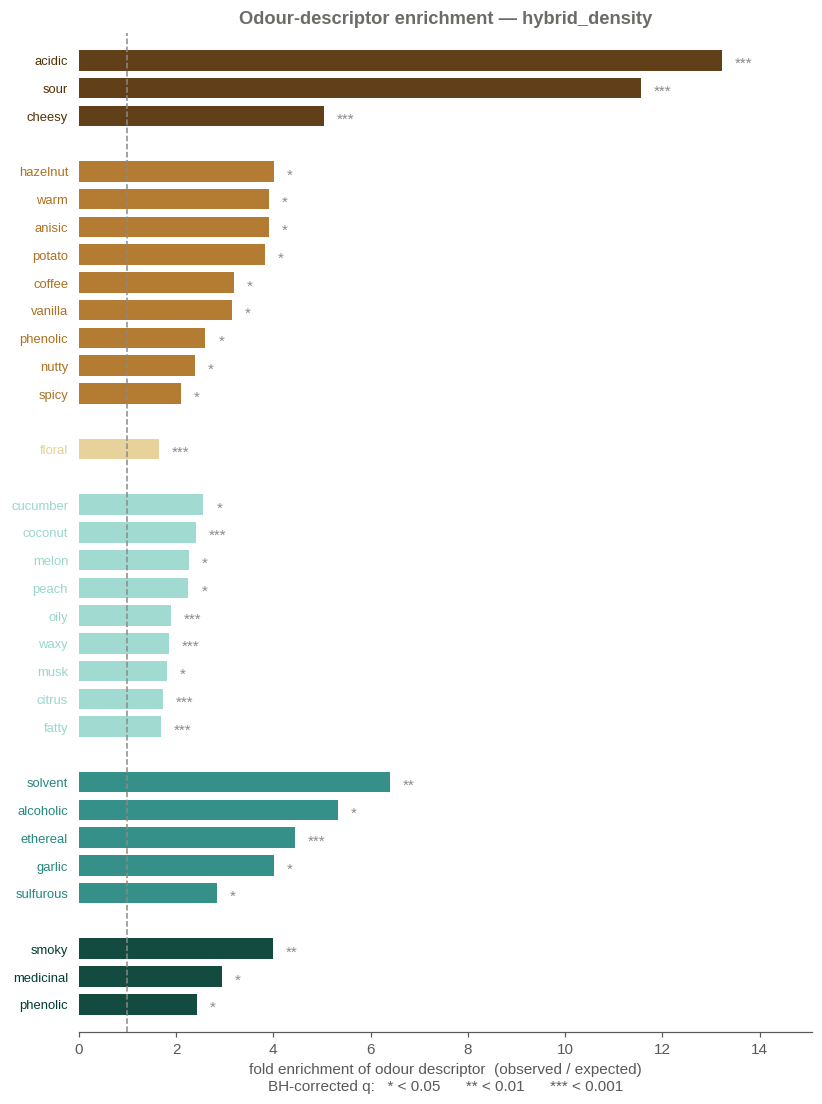

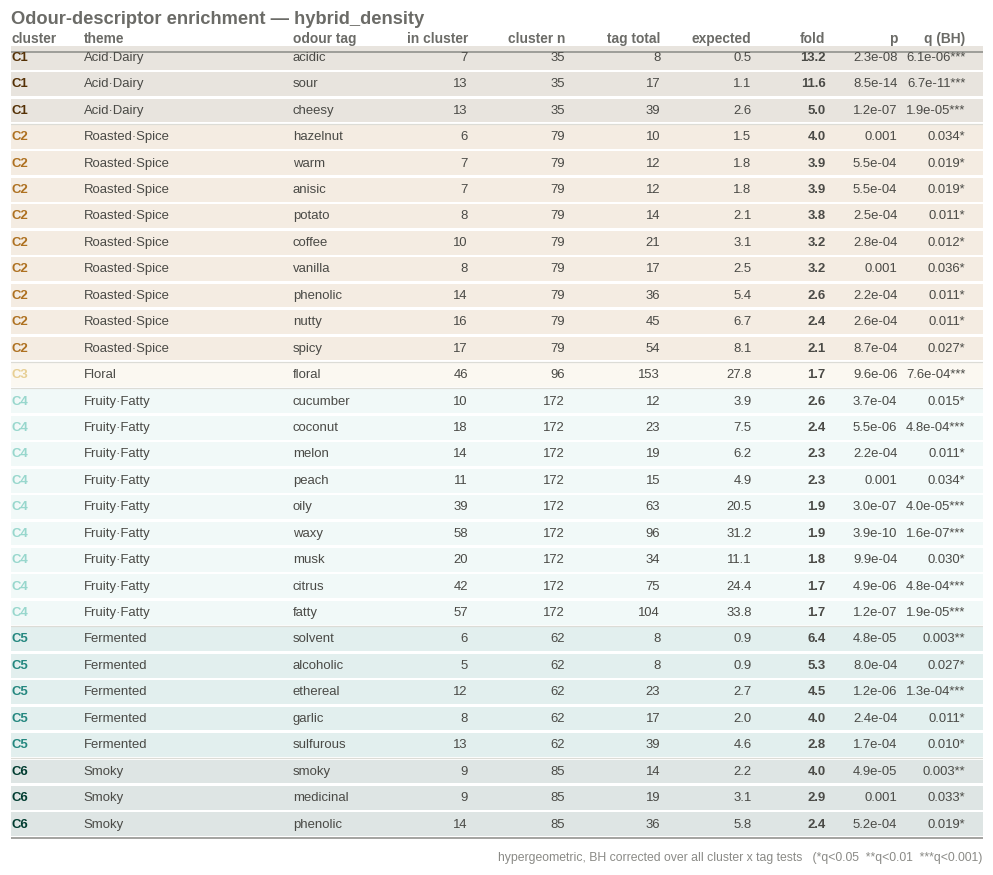

In [17]:
enrichment.sort_values(["cluster", "fdr"]).to_csv(TABLES / f"enrichment_{NAME}.csv", index=False)
af.enrichment_bars(significant, info, display_order, f"Odour-descriptor enrichment — {NAME}",
                   FIGURES / f"enrichbar_{NAME}.svg", show=True)

enrichment_rows = af.enrichment_table_rows(significant, info, display_order)
enrichment_rows.drop(columns="color").to_csv(TABLES / f"enrichment_table_{NAME}.csv", index=False)
af.enrichment_table_figure(enrichment_rows, f"Odour-descriptor enrichment — {NAME}",
                           FIGURES / f"enrichment_table_{NAME}.svg", show=True)

## 6 · Cluster chemistry — Extended Data Fig. 4, Table 1, Supplementary Table 6

PCoA rather than PCA, because Jaccard distance is not Euclidean. The chemistry is one cluster
against all other clustered odorants: Fisher for functional groups, Cliff's delta with
Mann-Whitney for descriptors, BH within each figure.

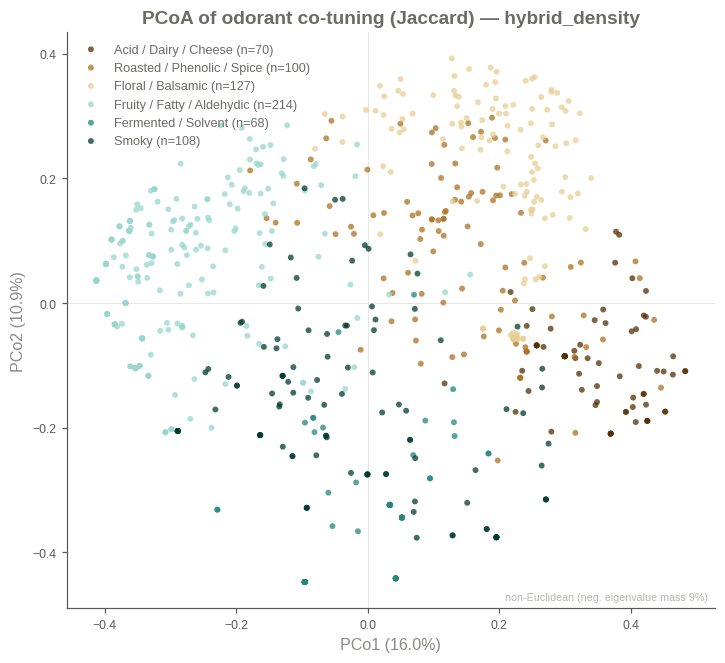

In [18]:
af.pcoa_figure(clustered_matrix, labels, info, display_order, f"PCoA of odorant co-tuning (Jaccard) — {NAME}",
               FIGURES / f"pcoa_{NAME}.svg", show=True)

687 odorants  sizes [70, 100, 127, 214, 68, 108]


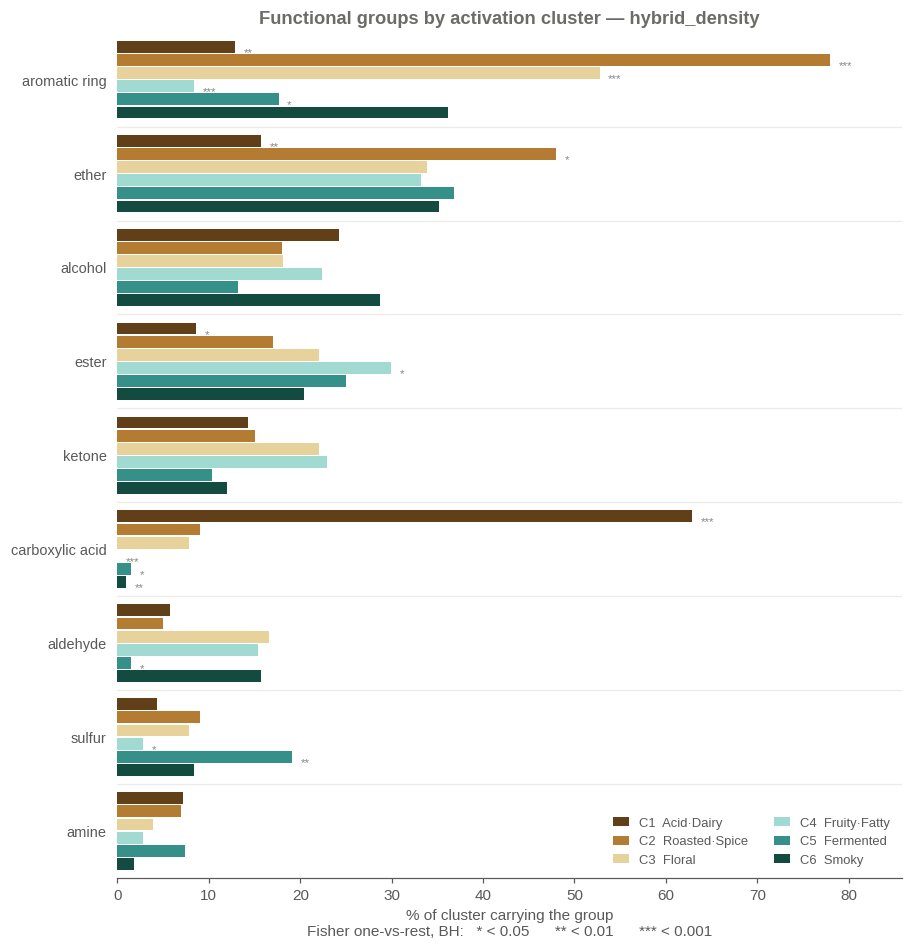

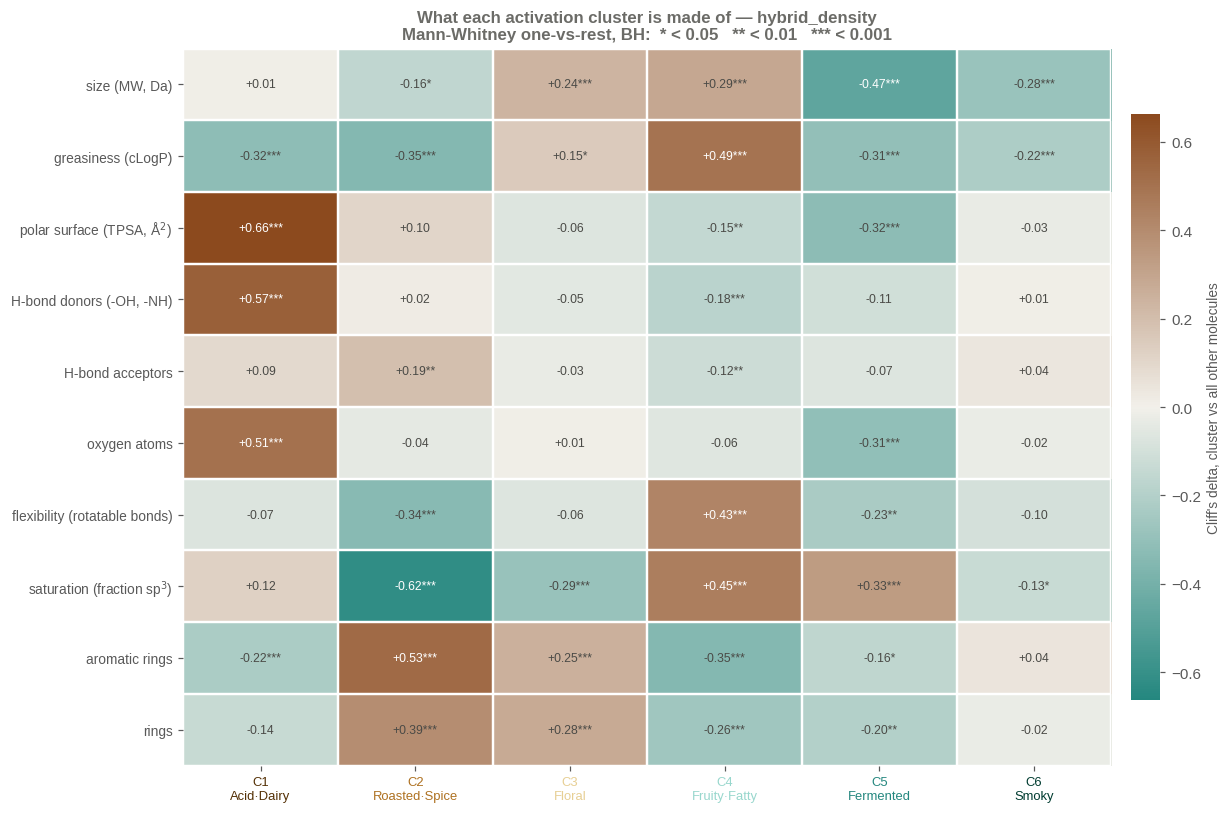

,cluster,theme,n,MolWt,LogP,TPSA,HBD,HBA,OxygenAtoms,RotBonds,...,RingCount,carboxylic acid,ester,aldehyde,ketone,alcohol,ether,aromatic ring,amine,sulfur
0,C1,Acid / Dairy / Cheese,70,159.207,1.817,37.30,1.0,1.5,2.0,2.5,...,0.0,62.9,8.6,5.7,14.3,24.3,15.7,12.9,7.1,4.3
1,C2,Roasted / Phenolic / Spice,100,149.685,1.885,26.30,0.0,2.0,1.0,2.0,...,1.0,9.0,17.0,5.0,15.0,18.0,48.0,78.0,7.0,9.0
2,C3,Floral / Balsamic,127,170.302,2.638,20.23,0.0,1.0,1.0,3.0,...,1.0,7.9,22.0,16.5,22.0,18.1,33.9,52.8,3.9,7.9
3,C4,Fruity / Fatty / Aldehydic,214,168.280,2.974,20.23,0.0,1.0,1.0,5.0,...,0.0,0.0,29.9,15.4,22.9,22.4,33.2,8.4,2.8,2.8
4,C5,Fermented / Solvent,68,130.187,1.724,20.23,0.0,1.5,1.0,2.0,...,0.0,1.5,25.0,1.5,10.3,13.2,36.8,17.6,7.4,19.1
5,C6,Smoky,108,138.222,1.982,20.23,0.0,2.0,1.0,2.0,...,1.0,0.9,20.4,15.7,12.0,28.7,35.2,36.1,1.9,8.3


In [19]:
cluster_descriptors = ac.odorant_descriptors(clustered_ids, smiles_by_odorant, labels)
cluster_descriptors["cluster_name"] = [info[c]["name"] for c in cluster_descriptors.cluster]
cluster_descriptors.to_csv(TABLES / f"chemspace_clusters_{NAME}_descriptors.csv", index=False)
print(f"{len(cluster_descriptors)} odorants  sizes {[int((cluster_descriptors.cluster == c).sum()) for c in display_order]}")

af.cluster_functional_groups(cluster_descriptors, info, display_order, NAME,
                             FIGURES / f"chemspace_clusters_{NAME}_groups.svg", show=True)
af.cluster_effects(cluster_descriptors, info, display_order, NAME,
                   FIGURES / f"chemspace_clusters_{NAME}_effects.svg", show=True)

cluster_summary = af.cluster_summary(cluster_descriptors, info, display_order)
cluster_summary.to_csv(TABLES / f"chemspace_clusters_{NAME}_summary.csv", index=False)
cluster_summary

## 7 · Biosynthetic pathway — Supplementary Table 10

NPClassifier pathway from COCONUT, joined on InChIKey, so only natural products have one.
Polyketides (12) and carbohydrates (3) are left out: with all seven classes too many expected
counts fall below 5 for chi-square. The control clusters the same odorants on ten standardised
descriptors, with no receptors involved. Both are read against a permutation floor. The
figures are in `supplementary/S4`.

In [20]:
pathway_result = ac.pathway_association(clustered_ids, labels, smiles_by_odorant, ODOURS, PATHWAYS)
pathways = pathway_result["pathways"]
pathway_all = pathway_result["pathway_all"]

print(f"panel odorants in COCONUT : {int(pathways.in_coconut.sum())} of {len(pathways)}")
print(f"clustered odorants        : {len(clustered_ids)}")
print(f"  with any pathway        : {int(pd.notna(pathway_all).sum())}")
print(f"  in the analysed classes : {int(pathway_result['use'].sum())}")
for name in ac.PATHWAYS_ANALYSED + ["Polyketides", "Carbohydrates"]:
    note = "" if name in ac.PATHWAYS_ANALYSED else "   (left out)"
    print(f"    {name:34s} {int((pathway_all == name).sum()):3d}{note}")
print()
for name, result in pathway_result["results"].items():
    print(f"{name:20s} Cramér V = {result['v']:.3f}   chi2 p = {result['p']:.3g}   "
          f"floor {result['floor']:.3f} (95th {result['floor95']:.3f})")

pathway_result["recovery"].to_csv(TABLES / "05_pathway_recovery.csv", index=False)
pathway_result["results"]["receptor clusters"]["ct"]

panel odorants in COCONUT : 536 of 754
clustered odorants        : 687
  with any pathway        : 442
  in the analysed classes : 427
    Fatty acids                        205
    Shikimates and Phenylpropanoids     84
    Terpenoids                          81
    Alkaloids                           45
    Amino acids and Peptides            12
    Polyketides                         12   (left out)
    Carbohydrates                        3   (left out)

receptor clusters    Cramér V = 0.356   chi2 p = 6.28e-35   floor 0.107 (95th 0.137)
descriptor clusters  Cramér V = 0.569   chi2 p = 2e-104   floor 0.108 (95th 0.138)


col_0,Alkaloids,Amino acids and Peptides,Fatty acids,Shikimates and Phenylpropanoids,Terpenoids
row_0,,,,,
0,6,2,16,22,28
1,1,0,100,6,21
2,1,7,19,5,12
3,9,0,35,14,10
4,22,1,6,34,6
5,6,2,29,3,4
